# Validation of proxy outputs for historical period

In [1]:
%cd ~/git/future_hail_global

/home/561/tr2908/git/future_hail_global


In [2]:
import sys
from pathlib import Path

import itertools

sys.path.append(f'{Path("~/git/xarray_parcel/").expanduser()!s}')
sys.path.append(f'{Path("~/git/warming_levels").expanduser()!s}')
sys.path.append(f'{Path("~/git/plotmap").expanduser()!s}')

import cartopy.crs as ccrs
import dask
import matplotlib.pyplot as plt
import modules.fut_hail as fh
import numpy as np
import xarray
from dask.distributed import Client

## Setup

In [3]:
_ = dask.config.set(**{'array.slicing.split_large_chunks': False})
client = Client(n_workers=12, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 12
Total threads: 12,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38541,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46229,Total threads: 1
Dashboard: http://127.0.0.1:36019/status,Memory: 10.43 GiB
Nanny: tcp://127.0.0.1:39221,


In [4]:
# ruff: noqa: E712                                # Don't check rule E712 in Ruff.
plt.show()  # Start the plotting engine.
plt.rcParams['font.size'] = 16  # Font size for plots.
plt.rcParams['axes.formatter.useoffset'] = False  # Don't use offsets in plots.

lats = {
    'asia': slice(0, 55),  # Latitudes for selected world regions.
    'oceania': slice(-48, 0),
    'north_america': slice(12, 60),
    'south_america': slice(-57, 12),
    'europe': slice(25, 70),
    'africa': slice(-37, 25),
}

lons = {
    'asia': slice(55, 147),  # Longitudes for selected world regions.
    'oceania': slice(98, 180),
    'north_america': slice(-130, -50),
    'south_america': slice(-100, -20),
    'europe': slice(-12, 55),
    'africa': slice(-20, 55),
}

region_names = {
    'asia': 'Asia',  # Display names for selected world regions.
    'oceania': 'Oceania',
    'north_america': 'North America',
    'south_america': 'South America',
    'europe': 'Europe',
    'africa': 'Africa',
}

In [5]:
dat, landmask = fh.read_processed_data(apply_landmask=False)
era5 = fh.era5_climatology(landmask=None)

In [7]:
proxies = ['Raupach2023_updated', 'Eccel2012', 'SHIP_0.1']

In [8]:
models = xarray.merge([dat.sel(epoch='historical', proxy=proxies).annual_hail_days.mean('year_num'),
                       era5.annual_hail_days.sel(proxy=proxies).expand_dims({'model': ['ERA5']})])

In [ ]:
from importlib import reload
import plotmap

reload(fh)
reload(plotmap)

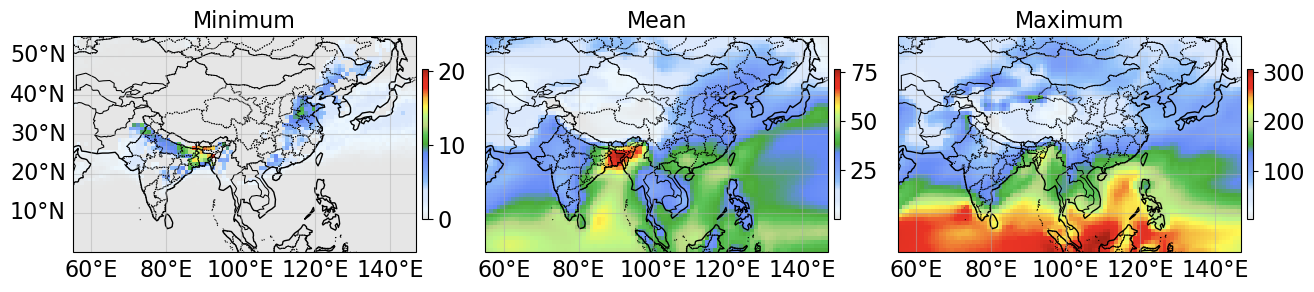

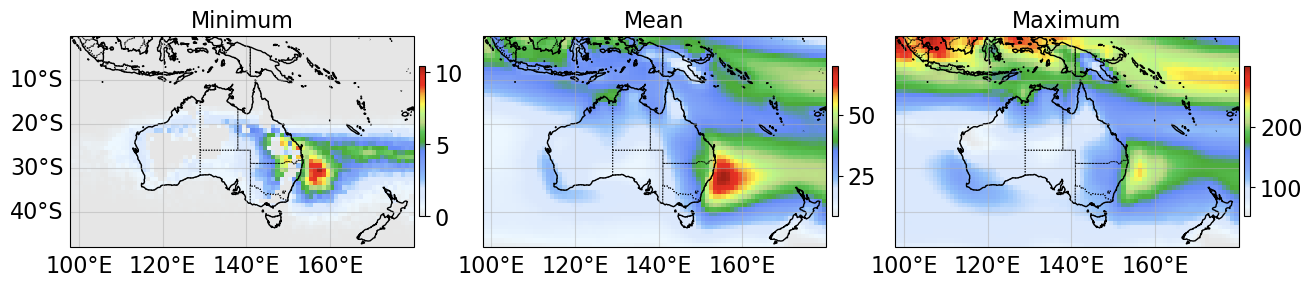

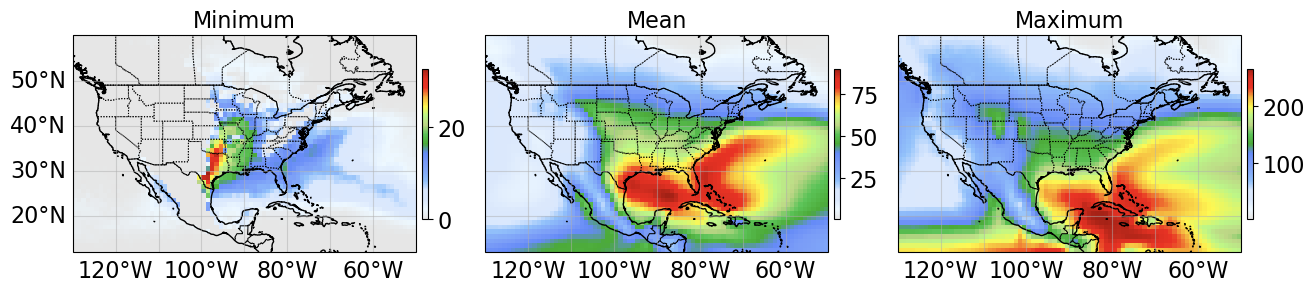

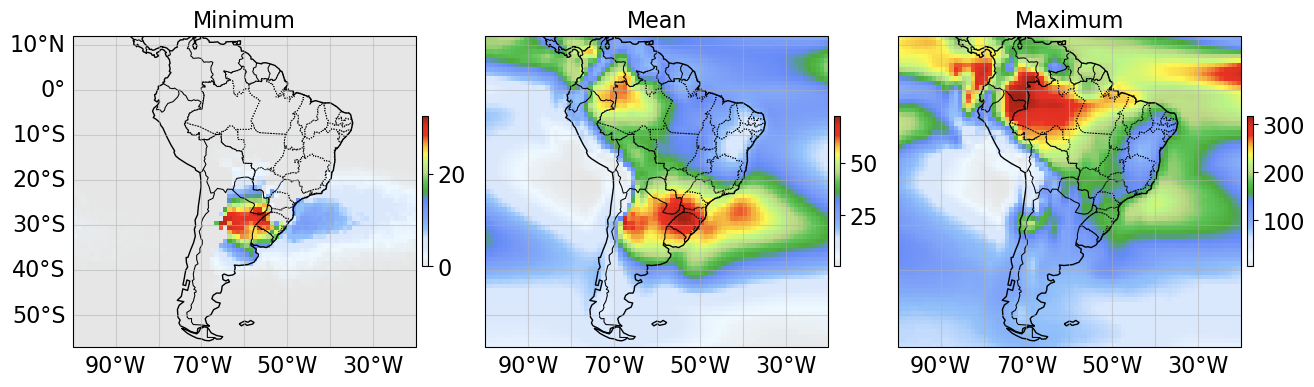

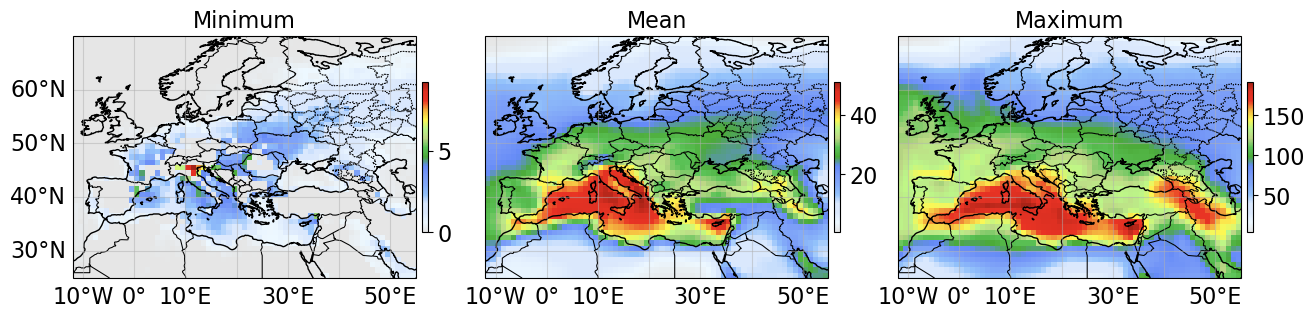

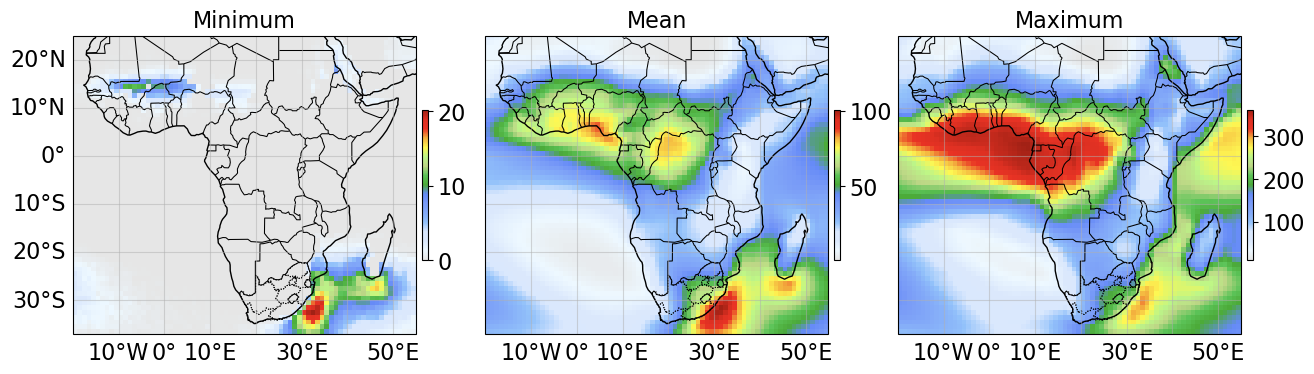

In [ ]:
for region in region_names:
    d = [
        models.min(['model', 'proxy']).annual_hail_days.sel(lat=lats[region], lon=lons[region]),
        models.mean(['model', 'proxy']).annual_hail_days.sel(lat=lats[region], lon=lons[region]),
        models.max(['model', 'proxy']).annual_hail_days.sel(lat=lats[region], lon=lons[region]),
    ]

    fh.plot_map(
        d,
        title=['Minimum', 'Mean', 'Maximum'],
        cbar_label='',
        ncols=3,
        figsize=(12, 5),
        wspace=0.1,
        share_axes=True,
        cbar_shrink=0.3,
        cmap=fh.hail_cmap,
        file=f'results/supplementary/proxy_climatology_{region}.pdf',
        country_borders=True,
    )